In [14]:
# Import necessary libraries and our database modules
import time
import random
import matplotlib.pyplot as plt
import pandas as pd

from db_manager import DatabaseManager
from bruteforce import BruteForceDB

# Initialize our Database Manager and create a test table
db = DatabaseManager()
b_tree_table = db.create_table("BenchmarkTable", b_tree_order=4)
brute_force_db = BruteForceDB()

print("Environment setup complete.")

Table 'BenchmarkTable' created successfully.
Environment setup complete.


In [16]:
# Benchmarking Configuration
data_sizes = range(100, 5000, 500) # Adjust sizes based on your system speed
results = {
    "Size": [],
    "BTree Insert": [], "Brute Insert": [],
    "BTree Search": [], "Brute Search": [],
    "BTree Range": [], "Brute Range": [],
    "BTree Delete": [], "Brute Delete": []
}

for size in data_sizes:
    results["Size"].append(size)

    # 1. Generate Random Keys
    keys = random.sample(range(1, size * 10), size)
    search_keys = random.sample(keys, size // 10) # Search 10% of keys
    range_start, range_end = min(keys), max(keys) // 2
    
    # --- INSERTION ---
    start = time.perf_counter()
    for k in keys: b_tree_table.insert_record(k, f"Val_{k}")
    results["BTree Insert"].append(time.perf_counter() - start)
    
    start = time.perf_counter()
    for k in keys: brute_force_db.insert(k,f"Val_{k}")
    results["Brute Insert"].append(time.perf_counter() - start)
    
    # --- SEARCH ---
    start = time.perf_counter()
    for k in search_keys: b_tree_table.get_record(k)
    results["BTree Search"].append(time.perf_counter() - start)
    
    start = time.perf_counter()
    for k in search_keys: brute_force_db.search(k)
    results["Brute Search"].append(time.perf_counter() - start)

    # --- RANGE QUERY ---
    start = time.perf_counter()
    b_tree_table.range_query(range_start, range_end)
    results["BTree Range"].append(time.perf_counter() - start)
    
    start = time.perf_counter()
    brute_force_db.range_query(range_start, range_end)
    results["Brute Range"].append(time.perf_counter() - start)

    # --- DELETION ---
    start = time.perf_counter()
    for k in search_keys: b_tree_table.delete_record(k)
    results["BTree Delete"].append(time.perf_counter() - start)

    start = time.perf_counter()
    for k in search_keys: brute_force_db.delete(k)
    results["Brute Delete"].append(time.perf_counter() - start)

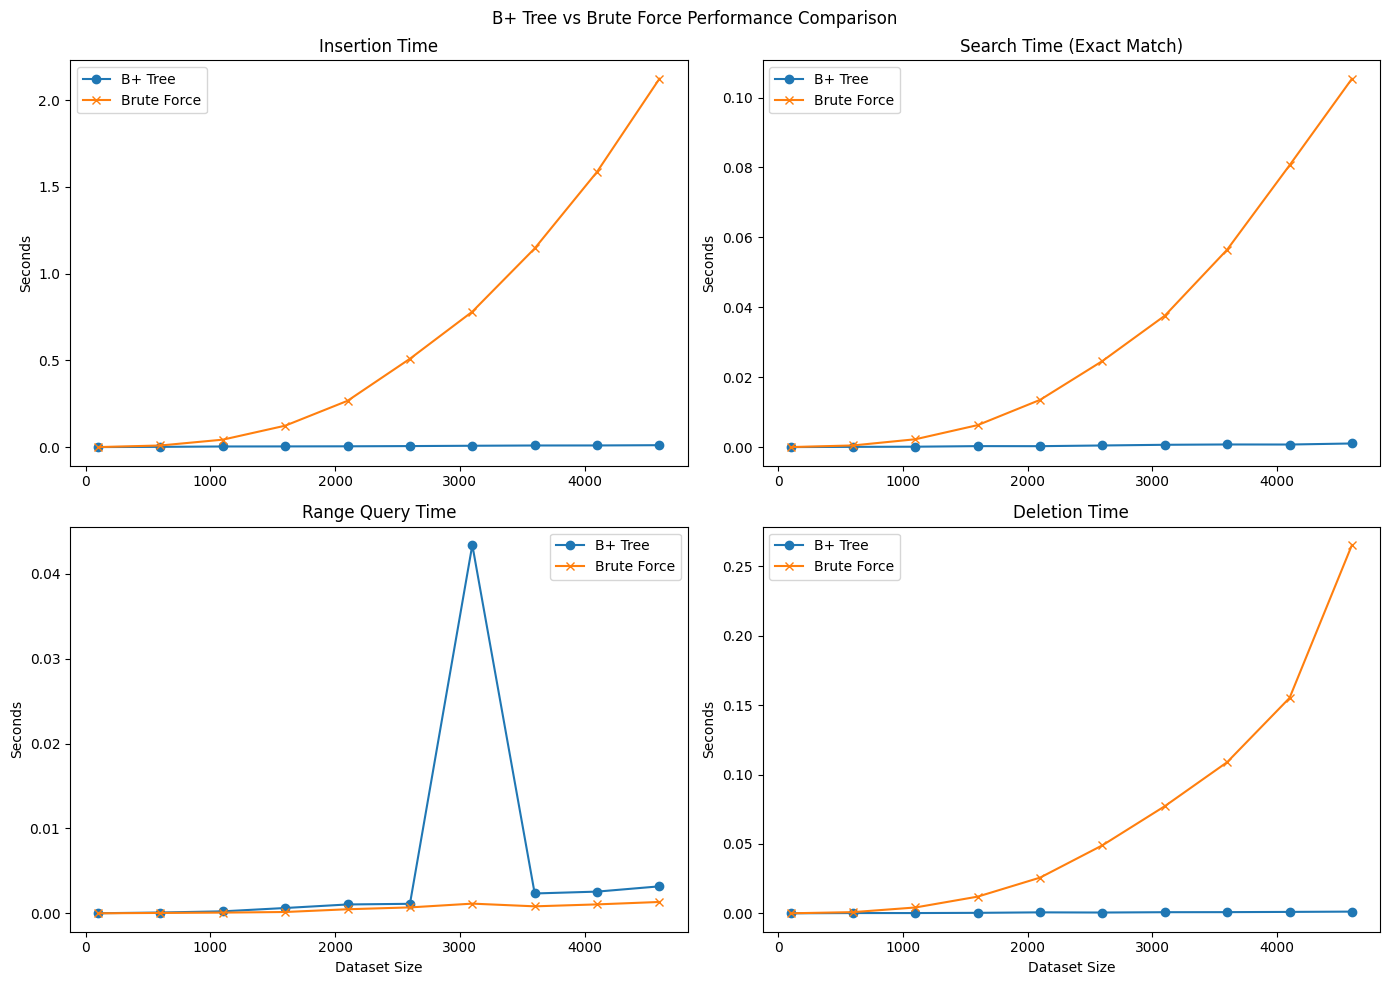

In [18]:
# Display tabular results
df = pd.DataFrame(results)
# display(df)

# Plotting the results using Matplotlib
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("B+ Tree vs Brute Force Performance Comparison")

# Insert Plot
axs[0, 0].plot(df["Size"], df["BTree Insert"], label="B+ Tree", marker='o')
axs[0, 0].plot(df["Size"], df["Brute Insert"], label="Brute Force", marker='x')
axs[0, 0].set_title("Insertion Time")
axs[0, 0].set_ylabel("Seconds")
axs[0, 0].legend()

# Search Plot
axs[0, 1].plot(df["Size"], df["BTree Search"], label="B+ Tree", marker='o')
axs[0, 1].plot(df["Size"], df["Brute Search"], label="Brute Force", marker='x')
axs[0, 1].set_title("Search Time (Exact Match)")
axs[0, 1].set_ylabel("Seconds")
axs[0, 1].legend()

# Range Plot
axs[1, 0].plot(df["Size"], df["BTree Range"], label="B+ Tree", marker='o')
axs[1, 0].plot(df["Size"], df["Brute Range"], label="Brute Force", marker='x')
axs[1, 0].set_title("Range Query Time")
axs[1, 0].set_xlabel("Dataset Size")
axs[1, 0].set_ylabel("Seconds")
axs[1, 0].legend()

# Delete Plot
axs[1, 1].plot(df["Size"], df["BTree Delete"], label="B+ Tree", marker='o')
axs[1, 1].plot(df["Size"], df["Brute Delete"], label="Brute Force", marker='x')
axs[1, 1].set_title("Deletion Time")
axs[1, 1].set_xlabel("Dataset Size")
axs[1, 1].set_ylabel("Seconds")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Table 'VizTable' created successfully.


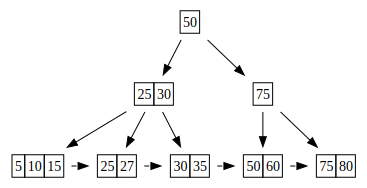

In [19]:
# Create a fresh, smaller table specifically for clean visualization
viz_table = db.create_table("VizTable", b_tree_order=4)

keys_to_insert = [50, 25, 75, 10, 30, 60, 80, 5, 15, 27, 35]
for key in keys_to_insert:
    viz_table.insert_record(key, f"Val_{key}")

# Generate and display the graph inside the notebook
dot = viz_table.index.visualize_tree()
dot

In [ ]:
# Initialize the overall Database System
my_db = DatabaseManager()

# 1. Create independent tables
users_table = my_db.create_table("Users", b_tree_order=4)
products_table = my_db.create_table("Products", b_tree_order=4)

print("\n--- Active Tables ---")
print(my_db.list_tables())

# 2. Insert records into the Users table
users_table.insert_record(101, {"name": "Alice", "role": "Admin"})
users_table.insert_record(102, {"name": "Bob", "role": "User"})
users_table.insert_record(105, {"name": "Charlie", "role": "User"})

# 3. Retrieve and update a record
print("\n--- Retrieving User 101 ---")
print(users_table.get_record(101))

print("\n--- Updating User 102 ---")
users_table.update_record(102, {"name": "Robert", "role": "User"})
print(users_table.get_record(102))

# 4. Perform a range query using the Table wrapper
print("\n--- Range Query (Users 100 to 104) ---")
print(users_table.range_query(100, 104))

# 5. Drop a table to show db_manager memory management
print("\n--- Dropping 'Products' Table ---")
my_db.drop_table("Products")
print("Remaining Tables:", my_db.list_tables())